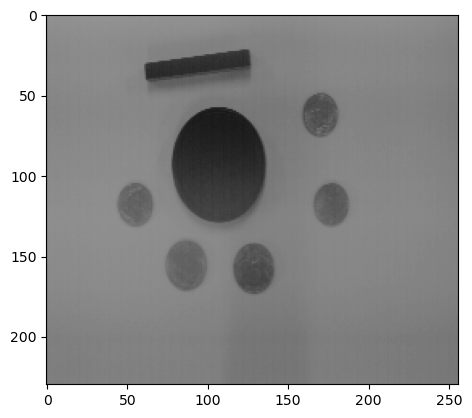

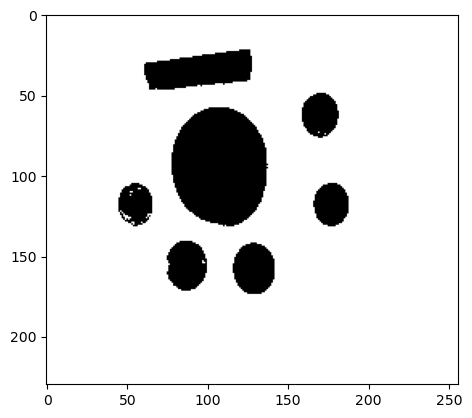

In [25]:
import cv2
import matplotlib.pyplot as plt

morpho = cv2.imread('MORPHO.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(morpho, cmap='gray', vmin=0, vmax=255)
plt.show()

umbral = 113
_, morphoU = cv2.threshold(morpho, umbral, 255, cv2.THRESH_BINARY)
plt.imshow(morphoU, cmap='gray', vmin=0, vmax=255)
plt.show()




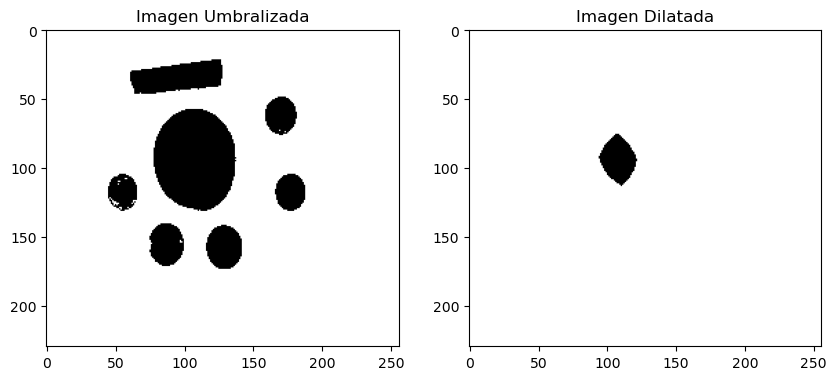

In [26]:
import numpy as np

kernel = np.ones((29, 29), np.uint8)
morphoUD = cv2.dilate(morphoU, kernel, iterations=1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Umbralizada")
plt.imshow(morphoU, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Dilatada")
plt.imshow(morphoUD, cmap="gray", vmin=0, vmax=255)
plt.show()


### ¿Qué obtiene como resultado?

El resultado de aplicar la dilatación con la máscara de 29x29 es que todas las figuras de menor tamaño han desaparecido mientras que el circulo grande ha reducido su tamaño de manera significativa mientras y su forma ha cambiado a algo que parece ser un rombo.

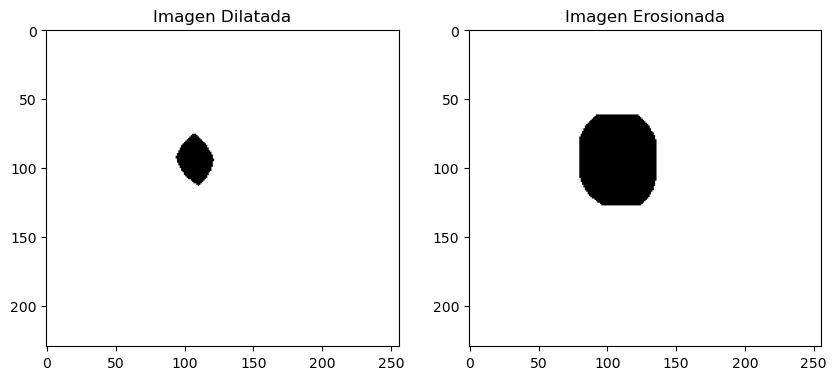

In [27]:
morphoUDE = cv2.erode(morphoUD, kernel, iterations=1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Dilatada")
plt.imshow(morphoUD, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Erosionada")
plt.imshow(morphoUDE, cmap="gray", vmin=0, vmax=255)
plt.show()


### ¿Cómo es el objeto obtenido con respecto al original?

Parece que con la erosión agregada, la imagen ha pasado de ser rombo a ser un cuadrado con las esquinas redondeadas y no un circulo como en su forma original. Parece ser que la función utilizada pretende agregar masa dentro de la figura solamente separando sus bordes y aplicando un relleno que no recupera los bordes de la forma original.

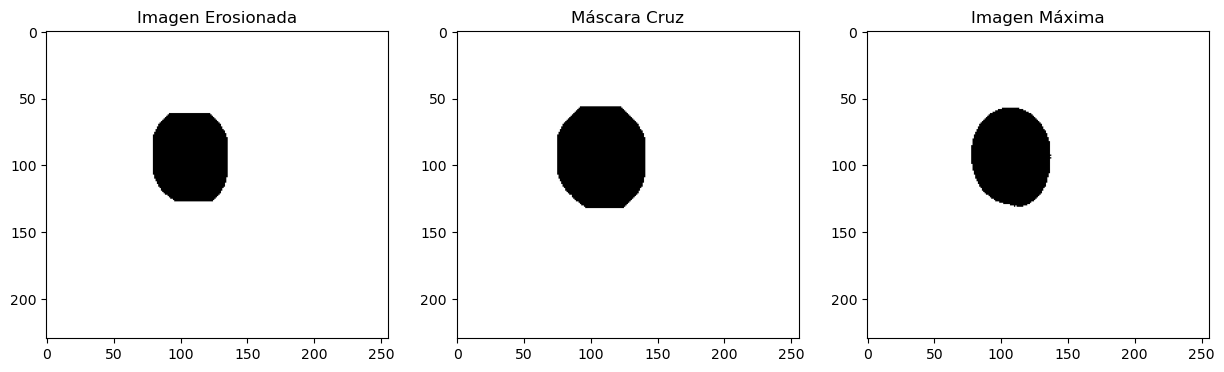

In [28]:
kernel = np.zeros((11, 11), np.uint8)
kernel[5, :] = 1
kernel[:, 5] = 1
morphoUDEC = cv2.erode(morphoUDE, kernel, iterations=1)
morphoUM = np.maximum(morphoU, morphoUDEC)

plt.figure(figsize=(15, 20))
plt.subplot(1, 3, 1)
plt.title("Imagen Erosionada")
plt.imshow(morphoUDE, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 3, 2)
plt.title("Máscara Cruz")
plt.imshow(morphoUDEC, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 3, 3)
plt.title("Imagen Máxima")
plt.imshow(morphoUM, cmap="gray", vmin=0, vmax=255)
plt.show()

### ¿Cómo es el resultado obtenido?

El resultado obtenido es casi identico a la forma del la imagen original umbralizada, pero sin rastro del resto de objetos pequeños.

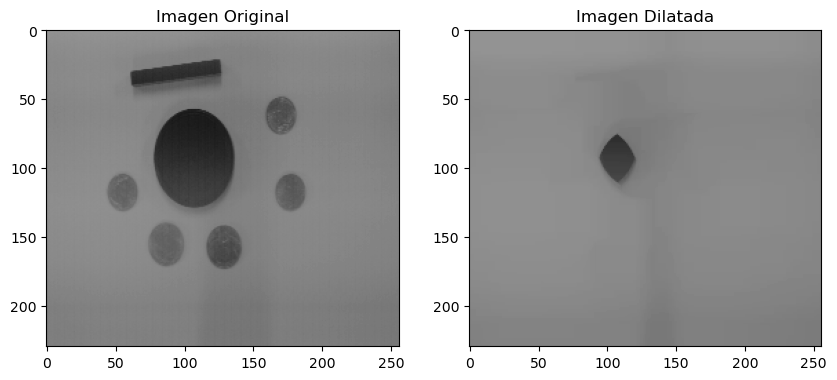

In [29]:
kernel = np.ones((29, 29), np.uint8)
morphoD = cv2.dilate(morpho, kernel, iterations=1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Original")
plt.imshow(morpho, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Dilatada")
plt.imshow(morphoD, cmap="gray", vmin=0, vmax=255)
plt.show()


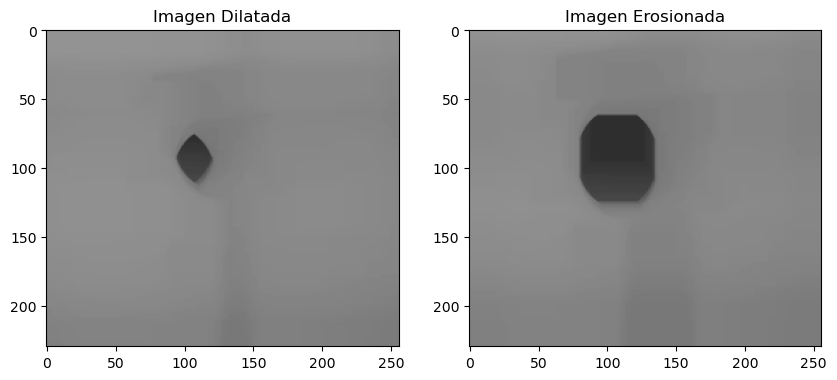

In [30]:
morphoDE = cv2.erode(morphoD, kernel, iterations=1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Dilatada")
plt.imshow(morphoD, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Erosionada")
plt.imshow(morphoDE, cmap="gray", vmin=0, vmax=255)
plt.show()

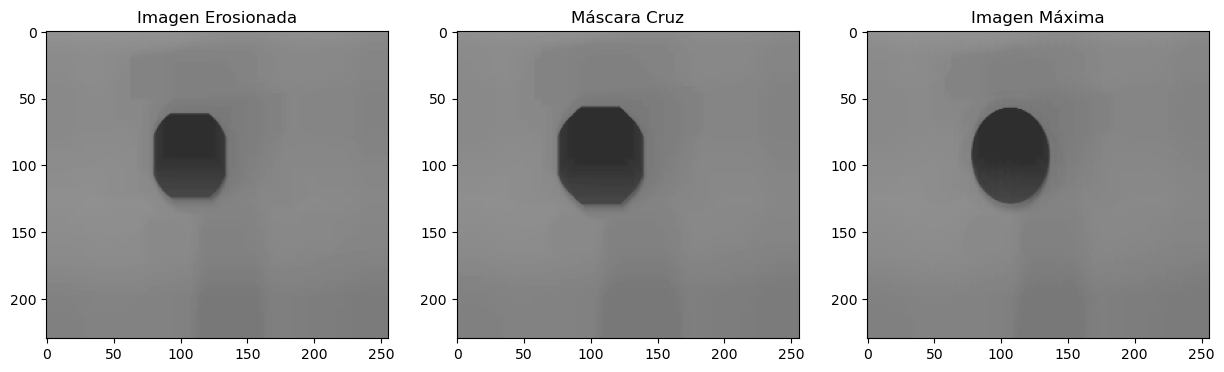

In [31]:
kernel = np.zeros((11, 11), np.uint8)
kernel[5, :] = 1
kernel[:, 5] = 1
morphoDEC = cv2.erode(morphoDE, kernel, iterations=1)
morphoM = np.maximum(morpho, morphoDEC)

plt.figure(figsize=(15, 20))
plt.subplot(1, 3, 1)
plt.title("Imagen Erosionada")
plt.imshow(morphoDE, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 3, 2)
plt.title("Máscara Cruz")
plt.imshow(morphoDEC, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 3, 3)
plt.title("Imagen Máxima")
plt.imshow(morphoM, cmap="gray", vmin=0, vmax=255)
plt.show()

### ¿Cómo funcionan las operaciones de erosión y dilatación en imágenes en niveles de gris?
La erosión y la dilatación en imágenes en niveles de gris funcionan seleccionando el valor mínimo o máximo dentro de una vecindad definida por una máscara. La dilatación reemplaza cada píxel por el valor máximo de su entorno, expandiendo regiones claras, mientras que la erosión reemplaza cada píxel por el valor mínimo, reduciendo las áreas brillantes y resaltando las oscuras. Estas operaciones modifican los detalles y el contraste de la imagen, siendo útiles para eliminar ruido y resaltar estructuras.  

### ¿Cómo es el resultado obtenido sobre la imagen en niveles de gris, comparado con el resultado sobre la imagen binaria?
Al ver el resultado de repetir el proceso con la imagen original sin umbralizar, nos podemos dar cuenta de que el resultado no fue el esperado. En imágenes binarias, la erosión y la dilatación permiten recuperar la forma original de los objetos al eliminar detalles pequeños y restaurar estructuras más grandes. En imágenes en niveles de gris, estos procesos generan una transformación más difusa, afectando los valores de intensidad y produciendo una versión más suavizada y deformada del objeto, en lugar de mantener su forma exacta.